# Programming exercise 5: Collective Ising spins

Due on Monday, 18.05.2026, 20.00h

## The problem

The collective Ising spin model with a transverse field is governed by the Hamiltonian
$$
H=-\frac{J}{N}S_z^2 - \Omega S_x
$$
with the collective spin operators $S_\alpha = \sum_i \sigma_i^\alpha/2$, where $\sigma_i^\alpha$ is a Pauli operator acting on spin $i$. This model exhibits a quantum phase transition at $\Omega/J=1$, where the ground-state properties change abruptly, and a dynamical phase transition at $\Omega/J=0.5$, where the long-time dynamics changes qualitatively. The dynamical case was studied experimentally in a chain of trapped ions (https://www.nature.com/articles/nature24654). Note the different convention (x $\\leftrightarrow$ z) and the differences in the definitions of the field and interaction strengths used there. Also, in the experiment the interactions were not strictly infinite-range but followed a power law with a small exponent; the phenomenology is nevertheless the same.

We want to use this model to see how phase transitions can be observed numerically by extrapolating to infinite $N$, and to see how symmetries can be exploited to greatly reduce the size of the relevant Hilbert space of a spin system.

In [1]:
# load standard libraries

import numpy as np   # standard numerics library
import numpy.linalg as LA
import scipy.linalg as sciLA

import matplotlib.pyplot as plt   # for making plots

import time

import scipy.sparse as sparse
import scipy.sparse.linalg as sLA

import Comp_Quant_Dynam as cqd

### Exercise 1

We first want to study the low-lying eigenstates and observe the quantum phase transition. It therefore makes sense to work with sparse matrices.

Build the Hamiltonian as a sparse matrix in the Dicke basis. Proceed similarly to the coupled oscillator problem from Programming exercise 4: build the matrix representation of the collective spin operators $S_+$ and $S_z$, and then use these to construct the remaining operators you need, e.g. $S_x=(S_+ + S_-)/2$. For matrix-matrix and matrix-vector multiplication it is convenient to use the @ operator, which is shorthand for dot().

It is crucial that you use the Dicke basis as discussed in the lecture. That way you only need $N+1$ basis states, which is a huge reduction of complexity compared to the product Hilbert space of $N$ spin-$1/2$ particles, whose size is $2^N$.

Test your implementation for $N=20$ by using small and large values of $\Omega$ and comparing, qualitatively, to the expectation values of $S_z^2$ and $S_x$ in the ground state in either limit. Set $J=1$ from now on, so times are measured in units of $1/J$ and when we write $\Omega$ we really mean the dimensionless parameter $\Omega/J$.

In [2]:
# testing
N = 10  # number of spins
ome = 0.1  # transverse field strength

Sx = cqd.operators.Sx_sparse(N)
Sz = cqd.operators.Sz_sparse(N)

H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)
evals, evecs = sLA.eigsh(H_mat, k=1, which='SA')

print(cqd.utility.expectation_value(evecs[:, 0], Sx))
print(cqd.utility.expectation_value(evecs[:, 0], Sz @ Sz))

0.5559908443633719
24.721895181758466


### Exercise 2

Loop over $\Omega$ from 0 to 2 in small steps using at least $N=100$, and record the lowest three eigenenergies and, for the ground state, the probabilities $P(M)$ to find the system in the Dicke state $|N/2,M\rangle$.
Plot $P(M;\Omega)$ in a density plot (e.g. using plt.imshow()). At small $\Omega$ you should observe that the ground state contains only components with large $z$-magnetization, while at large $\Omega$ the distribution is peaked around $M=0$. In between, the quantum phase transition occurs.

For small $\Omega$ one observes a kind of spontaneous symmetry breaking: the gap between the ground and first excited state becomes very small. The states $|00...0\rangle = |N/2,N/2\rangle$ and $|11...1\rangle = |N/2,-N/2\rangle$ are degenerate ground states at $\Omega=0$. The Hamiltonian has a $Z_2$ symmetry: it is invariant under flipping all spins. Thus the eigenstates should also respect this symmetry and be either symmetric or anti-symmetric with respect to spin flips. However, when the gap between the symmetric and anti-symmetric ground state becomes too small, the numerical diagonalization algorithm just randomly chooses a superposition of the two states, which can just as well be $|N/2,-N/2\rangle$ or $|N/2,N/2\rangle$, thus breaking the symmetry.

Optional:

We now want to analyze the gap between the ground and excited states. At a quantum phase transition, the gap closes in the thermodynamic limit ($N\rightarrow\infty$). The spin-flip symmetry means that, if written in the symmetrized basis, the Hamiltonian consists of two disconnected blocks, representing the symmetric ($\propto |N/2,M\rangle + |N/2,-M\rangle$) and anti-symmetric states ($\propto |N/2,M\rangle - |N/2,-M\rangle$).

Plot the gap between the ground and first excited state ($\delta_{0,1}=E_1-E_0$) and the ground and second excited state ($\delta_{0,2}$). You should see that the gap $\delta_{0,1}$ becomes very small in the ferromagnetic phase ($\Omega<1$). This is the gap between the symmetric and anti-symmetric ground states. The relevant gap for the phase transition is $\delta_{0,2}$, which is the gap between the ground and first excited state within the symmetric block. This should show a minimum near the phase transition point.

One could also fix the symmetry problem by considering the symmetric and anti-symmetric blocks separately. For this you need to implement the Hamiltonian again in the symmetrized basis, or use a basis transformation into the symmetrized basis. This will give a speedup of at least a factor of 2.

In [3]:
# loop over omega to study the ground state and gap (use un-symmetrized version)

N = 200 # number of spins
dim = N + 1 # dimension of the Hilbert space
n_evals_comp = 3 # number of eigenvalues to compute

# loop over omega
omevec = np.linspace(0, 2, 50)

# containers
evals_all = np.zeros((n_evals_comp, len(omevec)))
gs_all = np.zeros((dim, len(omevec)))

for i in range(len(omevec)):
    # build the Hamiltonian
    H_mat = cqd.hamiltonians.build_H_TFIM(N, omevec[i])
    # diagonalize
    evals, evecs = sLA.eigsh(H_mat, k=n_evals_comp, which='SA')
    evals_all[:, i] = evals
    gs_all[:, i] = evecs[:, 0]

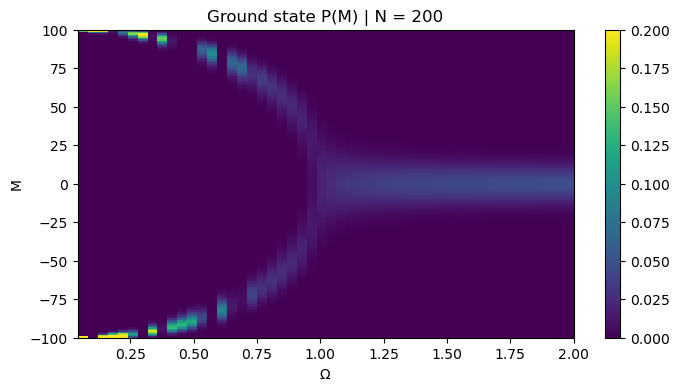

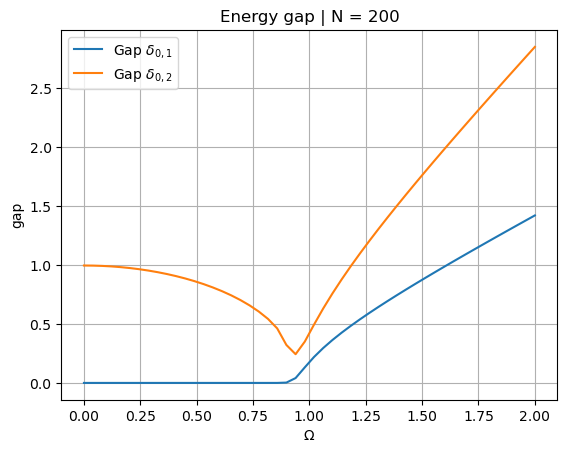

In [4]:
plt.figure(figsize=(8, 4))
plt.imshow(np.abs(gs_all) ** 2, extent=[omevec[1], omevec[-1], -N / 2, N / 2], clim=(0.0, 0.2), aspect='auto', interpolation='none')
plt.colorbar()

plt.xlabel('$\\Omega$')
plt.ylabel('M')
plt.title('Ground state P(M) | N = ' + str(N))
plt.show()

plt.plot(omevec, evals_all[1] - evals_all[0], label='Gap $\\delta_{0,1}$')
plt.plot(omevec, evals_all[2] - evals_all[0], label='Gap $\\delta_{0,2}$')
plt.title('Energy gap | N = ' + str(N))
plt.xlabel('$\\Omega$')
plt.ylabel('gap')
plt.legend()
plt.grid()
plt.show()

### Exercise 3 (optional)

Study how the gap $\delta_{0,2}=E_2-E_0$ at the critical point closes for large $N$ (finite-size scaling analysis). Determine the position and size of the smallest gap as a function of $N$. Loop $N$ from 40 to 400 in steps of 20. The easiest way to obtain the minimal gap is to calculate it on an $\Omega$ grid around 1, where the transition is expected. For example, increase $\Omega$ from 0.8 to 1 in 100 steps. You could also make the search for the minimal gap more efficient by implementing an iterative search procedure.

Plot the resulting distance of the optimal $\Omega$ from 1 and the size of the minimal gap on double-logarithmic scales. You should obtain a power-law behavior. Extract the exponent of this power law for both the minimal gap and its distance from 1.

In [5]:
# loop over omega and N to study the N-dependence of the gap
n_evals_comp = 3

N_vec = np.arange(40, 410, 20)
omevec = np.linspace(0.8, 1.0, 100)

evals_all = np.zeros((n_evals_comp, len(omevec), len(N_vec)))
minGap = np.zeros((2, len(N_vec)))

for j in range(len(N_vec)):
    N = N_vec[j]
    print(f"Computing for N = {N}")
    dim = N + 1
    for i in range(len(omevec)):
        # build the Hamiltonian
        #H_mat = cqd.hamiltonians.build_H_TFIM(N, omevec[i])
        H_mat = cqd.hamiltonians.build_H_TFIM_symm(N, omevec[i])
        # diagonalize
        evals, evecs = sLA.eigsh(H_mat, k=n_evals_comp, which='SA')
        evals_all[:, i, j] = evals
    # find position and value of smallest gap
    iOmeMin = np.argmin(evals_all[2, :, j] - evals_all[0, :, j])
    minGap[:, j] = [omevec[iOmeMin], evals_all[2, iOmeMin, j] - evals_all[0, iOmeMin, j]]

Computing for N = 40
Computing for N = 60
Computing for N = 80
Computing for N = 100
Computing for N = 120
Computing for N = 140
Computing for N = 160
Computing for N = 180
Computing for N = 200
Computing for N = 220
Computing for N = 240
Computing for N = 260
Computing for N = 280
Computing for N = 300
Computing for N = 320
Computing for N = 340
Computing for N = 360
Computing for N = 380
Computing for N = 400


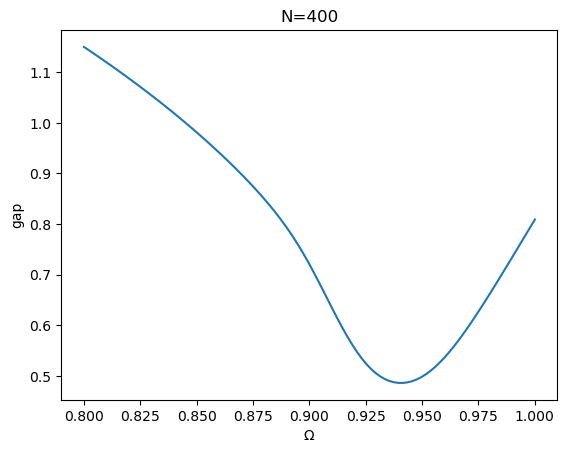

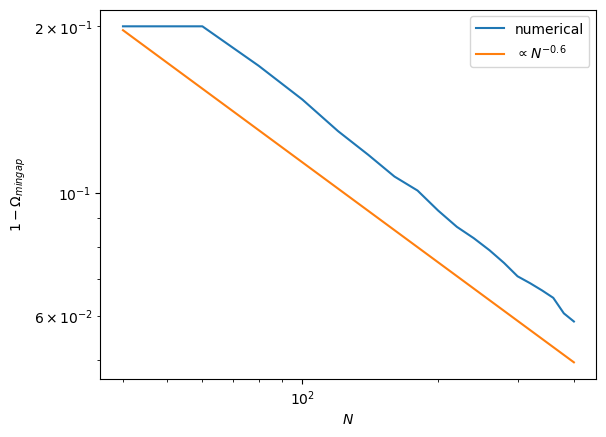

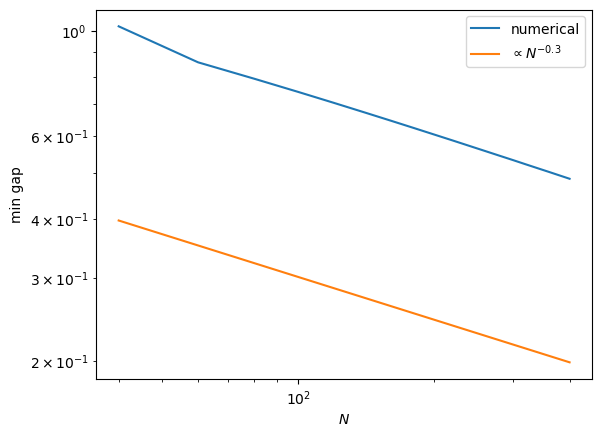

In [6]:
iN = -1  # index of N to plot

plt.plot(omevec, evals_all[2, :, iN] - evals_all[0, :, iN], label='Gap $\\delta_{0,2}$')
plt.xlabel('$\\Omega$')
plt.ylabel('gap')
plt.title(f'N={N_vec[iN]}')
plt.show()

plt.loglog(N_vec, 1 - minGap[0], label='numerical')
plt.loglog(N_vec, 1.8 / N_vec ** (0.6), label='$\\propto N^{-0.6}$')
#plt.plot(N_vec,1-minGapSym[0])
plt.xlabel('$N$')
plt.ylabel('$1-\\Omega_{min gap}$')
plt.legend()
plt.show()

plt.loglog(N_vec, minGap[1], label='numerical')
plt.loglog(N_vec, 1.2 / N_vec ** (0.3), label='$\\propto N^{-0.3}$')
#plt.plot(N_vec,minGapSym[1])
plt.xlabel('$N$')
plt.ylabel('min gap')
plt.legend()
plt.show()
#minGapSym = minGap

The gap decays as $N^{-0.3}$ and the minimum approaches 1 as $N^{-0.6}$. Can one calculate these exponents analytically? What is their significance?

### Exercise 4

Now calculate the time evolution under the above Hamiltonian, starting in the state $|11...1\rangle = |N/2,-N/2\rangle$. The most straightforward way to do this is to use SciPy's `expm` function, which allows you to exponentiate a matrix directly so you can calculate $\exp(-iHt)$ and apply it to the initial state (e.g. using the @ operator). Try this out, keeping in mind that `expm` expects a dense matrix as input, so if you worked with sparse matrices in the previous exercises you may have to convert $H$ to a dense matrix. You will see that it becomes really slow as you go to larger atom numbers. The more efficient way is to use exact diagonalization. As we need all eigenstates for this, sparse matrices do not give an advantage in this case. Also, the spin-flip symmetry is not so useful here since our initial state already breaks this symmetry.

To calculate $|\psi(t)\rangle$, project the initial state onto the eigenstates. Remember that the eigenstates are in the columns of the eigenvector matrix returned by eig (or eigh). Thus the transformation into the energy eigenbasis can be achieved by applying the conjugate transpose of this matrix to the initial state. Evolve the state in the eigenbasis and transform back.

Calculate the expectation values of $S_z$ and $S_z^2$ as a function of time for some value of $\Omega$ below and above 0.5. You should see different behavior in the two regimes. Check whether your results agree qualitatively with the observations in https://www.nature.com/articles/nature24654, in particular Fig. 2 (the paper is also on arxiv: https://arxiv.org/abs/1708.01044). Note that their definition of the parameter $\Omega/J$ differs by a factor 1/2 from ours, so the transition point is at 1 for them.

In [7]:
N = 200
dim = N + 1  # Hilbert space dimension will be N+1

Sx = cqd.hamiltonians.Sx_sparse(N)
Sz = cqd.hamiltonians.Sz_sparse(N)
Sz2 = Sz @ Sz

# build the Hamiltonian
ome = 0.2
H_mat = cqd.hamiltonians.build_H_TFIM(N, ome)
H_mat_dense = H_mat.toarray()

# initial state: all in 0
ini = np.eye(1, dim, 0)[0]

dt = 0.1
tsteps = 100
tvec = cqd.utility.create_tvecs(tsteps, dt)

# calculate the time evolution using the matrix exponential
t1 = time.time()
observables = np.zeros((1, len(tvec)), dtype=complex)
Psit = ini.copy()
U_expm_dt = sciLA.expm(-1j * H_mat_dense * dt)  # compute the time evolution operator for one time step
for i in range(len(tvec)):
    #Psit = sciLA.expm(-1j * H_mat_dense * tvec[i]) @ ini # even worse
    Szval = cqd.utility.expectation_value(Psit, Sz)
    observables[0, i] = Szval
    Psit = U_expm_dt @ Psit

t2 = time.time()
print('time for matrix exponential was ' + str(t2 - t1))

assert np.allclose(observables.imag, 0.0)

observables = observables.real

# calculate the time evolution using exact diagonalization
t1 = time.time()

evals, evecs = LA.eigh(H_mat_dense)

# calculate projections on eigenstates
iniProj = cqd.unitaries.init_coeffs_eigenbasis(ini, evecs) # evecs.conj().T @ ini

observables2 = np.zeros((1, len(tvec)), dtype=complex)
for i in range(len(tvec)):
    Psit = cqd.unitaries.t_evol_eigenbasis(iniProj, tvec[i], evals, evecs)
    Szval = cqd.utility.expectation_value(Psit, Sz)
    observables2[0, i] = Szval
t2 = time.time()
print('time for exact diagonalization was ' + str(t2 - t1))

assert np.allclose(observables2.imag, 0.0)
observables2 = observables2.real

time for matrix exponential was 0.05756258964538574
time for exact diagonalization was 0.02567744255065918


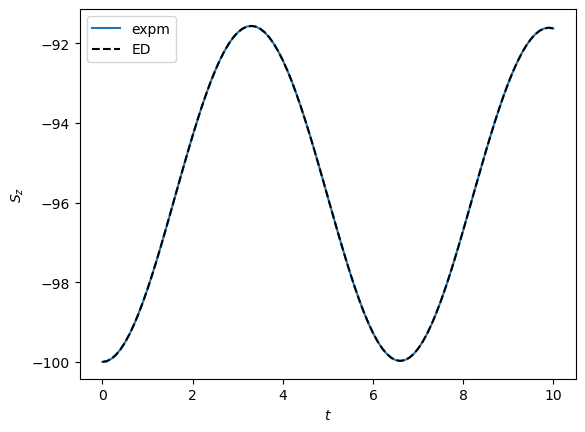

In [8]:
plt.plot(tvec, observables[0])
plt.plot(tvec, observables2[0], 'k--')
plt.xlabel('$t$')
plt.ylabel('$S_z$')
plt.legend(('expm', 'ED'))
plt.show()

In [9]:
N = 400
dim = N + 1 # Hilbert space dimension will be N+1

Sx = cqd.operators.Sx_sparse(N)
Sz = cqd.operators.Sz_sparse(N)
Sz2 = Sz @ Sz

# build the Hamiltonian
ome = 0.3
Hmat = cqd.hamiltonians.build_H_TFIM(N, ome).toarray()

# initial state: all in 0
ini = np.eye(1, dim, 0)[0]

tvec = np.linspace(0, 10, 101, endpoint=True)

evals, evecs = LA.eigh(Hmat)

# calculate projections on eigenstates
iniProj = cqd.unitaries.init_coeffs_eigenbasis(ini, evecs)

observables = np.zeros((2, len(tvec)), dtype=complex)
for i in range(len(tvec)):
    Psit = cqd.unitaries.t_evol_eigenbasis(iniProj, tvec[i], evals, evecs)
    Szval = cqd.utility.expectation_value(Psit, Sz)
    observables[0, i] = Szval
    Sz2val = cqd.utility.expectation_value(Psit, Sz2)
    observables[1, i] = Sz2val

assert np.allclose(observables.imag, 0.0)
observables = observables.real

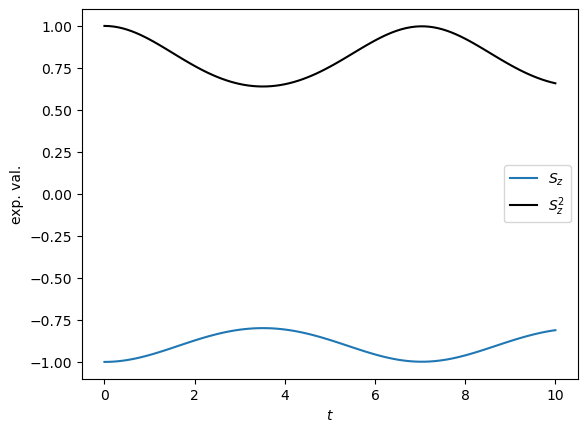

In [10]:
plt.plot(tvec, observables[0] / (N / 2))
plt.plot(tvec, observables[1] / (N / 2) ** 2, 'k')
plt.xlabel('$t$')
plt.ylabel('exp. val.')
plt.legend(('$S_z$', '$S_z^2$'))
plt.show()

For $\Omega<0.5$ the magnetization stays negative all the time. For $\Omega>0.5$ it can go to the other side of the Bloch sphere and become positive. 

### Exercise 5 (optional)

Study the long-time limit systematically as a function of $\Omega$. Loop $\Omega$ from 0 to 1 in at least 50 steps. Use at least $N=100$. Calculate the values of $S_z$ and $S_z^2$ at some long time. Also calculate the infinite-time average (diagonal ensemble value)
$$
\langle O \rangle_\infty = \sum_k |\langle \psi_0|\phi_k\rangle|^2 \langle \phi_k|O|\phi_k\rangle
$$
where $|\phi_k\rangle$ are the eigenstates and $O$ is the observable of interest (here $S_z$ or $S_z^2$).

Compare your results to Fig. 6 in https://arxiv.org/abs/1708.01044. This shows the dynamical phase transition.

In [11]:
N = 400
dim = N + 1
tlong = 100
ini = np.eye(1, dim, 0)[0]

# loop over omega
omevec = np.linspace(0, 1, 50)
observables = np.zeros((4, len(omevec)), dtype=complex)

Sz = cqd.operators.Sz_sparse(N)
Sz2 = Sz @ Sz

for i in range(len(omevec)):
    # build the Hamiltonian and observables
    H_mat = cqd.hamiltonians.build_H_TFIM(N, omevec[i]).toarray() # dense as we need all eigenvalues and eigenvectors
    # diagonalize
    evals, evecs = LA.eigh(H_mat)
    # calculate projections on eigenstates
    iniProj = cqd.unitaries.init_coeffs_eigenbasis(ini, evecs)
    # calculate values at long time
    Psit = cqd.unitaries.t_evol_eigenbasis(iniProj, tlong, evals, evecs)
    Szval = cqd.utility.expectation_value(Psit, Sz)
    Sz2val = cqd.utility.expectation_value(Psit, Sz2)
    # calculate infinite time average of observables
    Sz_diag_Els = [cqd.utility.expectation_value(evecs[:, k], Sz) for k in range(dim)]
    Sz2_diag_Els = [cqd.utility.expectation_value(evecs[:, k], Sz2) for k in range(dim)]
    Szinf = np.sum(Sz_diag_Els * abs(iniProj) ** 2)
    Sz2inf = np.sum(Sz2_diag_Els * abs(iniProj) ** 2)

    observables[:, i] = [Szval, Sz2val, Szinf, Sz2inf]

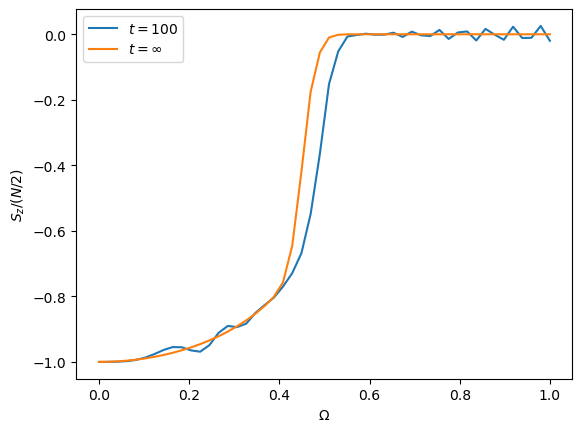

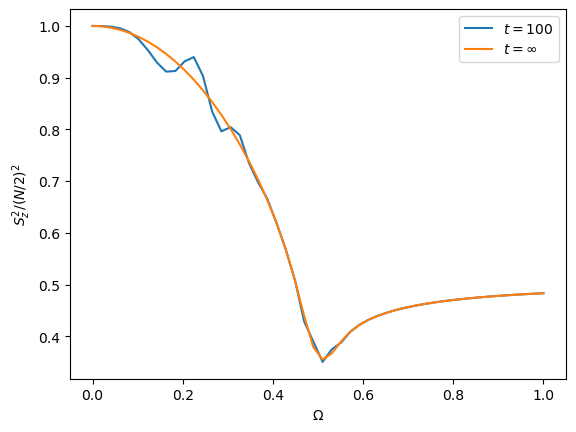

In [12]:
observables = observables.real

plt.plot(omevec, observables[0] / (N / 2))
plt.plot(omevec, observables[2] / (N / 2))
plt.xlabel('$\\Omega$')
plt.ylabel('$S_z / (N / 2)$')
plt.legend(('$t=100$', '$t=\\infty$'))
plt.show()
plt.plot(omevec, observables[1] / (N / 2) ** 2)
plt.plot(omevec, observables[3] / (N / 2) ** 2)
plt.xlabel('$\\Omega$')
plt.ylabel('$S_z^2 / (N / 2)^2$')
plt.legend(('$t=100$', '$t=\\infty$'))
plt.show()